## 🔵 DBSCAN  
### *Density-Based Spatial Clustering of Applications with Noise*

**Objetivos del notebook:**
- Entender cómo funciona DBSCAN
- Identificar sus parámetros principales
- Aplicarlo sobre un dataset real
- Interpretar los clusters y los puntos de ruido
- Comparar brevemente sus resultados con K-Means


---
## Aprendizaje no Supervisado y Clustering

### ¿Qué es el aprendizaje no supervisado?
Es una rama del *machine learning* que trabaja con datos **sin etiquetas**. Su objetivo es encontrar patrones, relaciones o grupos ocultos dentro de la información, sin que exista una respuesta correcta previamente definida.

**Casos de uso frecuentes:**
- Segmentación de clientes
- Detección de anomalías
- Sistemas de recomendación
- Análisis exploratorio de datos


### ¿Qué es *clustering*?
Es una técnica de aprendizaje no supervisado que agrupa observaciones similares entre sí y separa aquellas que son diferentes.  
La idea es que los elementos dentro de un mismo grupo compartan características parecidas, mientras que los grupos entre sí sean distintos.

---


## ¿Qué es DBSCAN?
DBSCAN es un algoritmo de clustering basado en **densidad**. Agrupa puntos que están suficientemente cerca entre sí y, al mismo tiempo, puede identificar observaciones aisladas como **ruido**.

A diferencia de K-Means:
- ✅ **No necesita definir el número de clusters por adelantado**
- ✅ **Puede detectar clusters de formas irregulares**
- ✅ **Puede identificar outliers o ruido**
- ⚠️ **Es sensible a la elección de `eps` y `min_samples`**


## Conceptos fundamentales

Los dos parámetros más importantes en DBSCAN son:

#### `eps` (ε)
Es la distancia máxima entre dos puntos para que se consideren vecinos.

Para estimarlo, suele usarse el **k-distance plot**:
- Se calcula la distancia al *k-ésimo vecino* de cada punto
- Se ordenan esas distancias
- Se busca el **codo** de la curva
- Ese cambio brusco da una pista de un buen valor de `eps`

#### `min_samples`
Es el número mínimo de puntos necesarios para considerar que una zona es suficientemente densa.

Como regla inicial, puede usarse un valor cercano a **2 × número de variables**. En este notebook trabajamos con **2 variables**, así que probaremos con `min_samples = 5` como punto de partida.


## Tipos de puntos

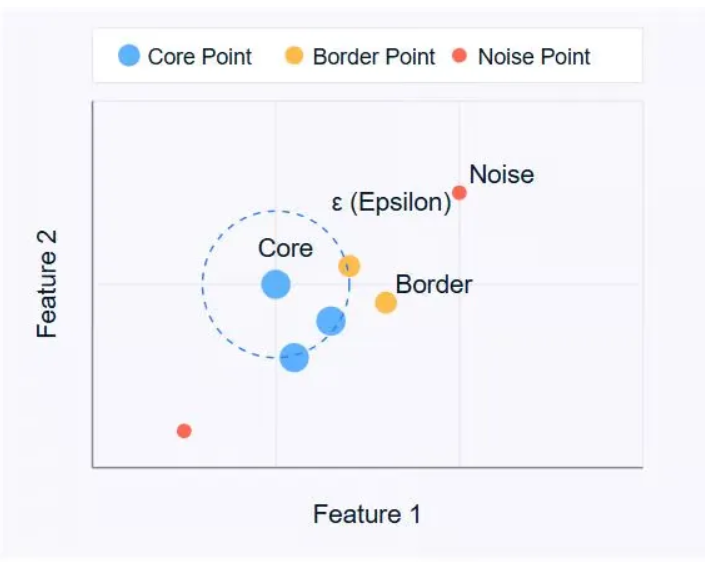

| Tipo de punto | Condición | Descripción / Rol |
|---|---|---|
| 🔵 **Punto núcleo** | Tiene al menos `min_samples` puntos dentro de un radio `eps` | Es la base para formar y expandir clusters |
| 🟡 **Punto borde** | Tiene menos de `min_samples` vecinos, pero está dentro del radio `eps` de un punto núcleo | Pertenece a un cluster, pero no lo expande |
| 🔴 **Punto ruido** | No cumple las condiciones anteriores | Se considera una observación aislada o atípica |


## 📊 Descripción del dataset
El dataset que usaremos contiene **200 clientes** de un centro comercial y **5 variables**:

- `CustomerID`
- `Genre`
- `Age`
- `Annual Income (k$)`
- `Spending Score (1-100)`

Para este ejemplo aplicaremos DBSCAN usando:
- **Annual Income (k$)**
- **Spending Score (1-100)**

Estas dos variables permiten visualizar patrones de comportamiento y segmentar clientes según sus ingresos y su nivel de gasto.


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN, KMeans
from sklearn.metrics import silhouette_score

plt.style.use("default")


In [16]:
df = pd.read_csv("data\Mall_Customers.csv")
df.head()


<>:1: SyntaxWarning: invalid escape sequence '\M'
<>:1: SyntaxWarning: invalid escape sequence '\M'
C:\Users\manue\AppData\Local\Temp\ipykernel_8004\2802978936.py:1: SyntaxWarning: invalid escape sequence '\M'
  df = pd.read_csv("data\Mall_Customers.csv")


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


### Vista general del dataset

In [17]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Genre                   200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 8.9 KB


### Selección de variables

In [18]:
features = ["Annual Income (k$)", "Spending Score (1-100)"]
X = df[features].copy()
X.head(10)


,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40
5,17,76
6,18,6
7,18,94
8,19,3
9,19,72


### Escalado de variables

DBSCAN trabaja con **distancias**, por lo que la escala influye directamente en el resultado.  
Aunque ambas variables están en rangos similares, es una buena práctica estandarizarlas antes de entrenar el modelo.


In [19]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pd.DataFrame(X_scaled, columns=features).head()


,Annual Income (k$),Spending Score (1-100)
0,-1.738999,-0.434801
1,-1.738999,1.195704
2,-1.700830,-1.715913
3,-1.700830,1.040418
4,-1.662660,-0.395980


### Visualización de los datos originales

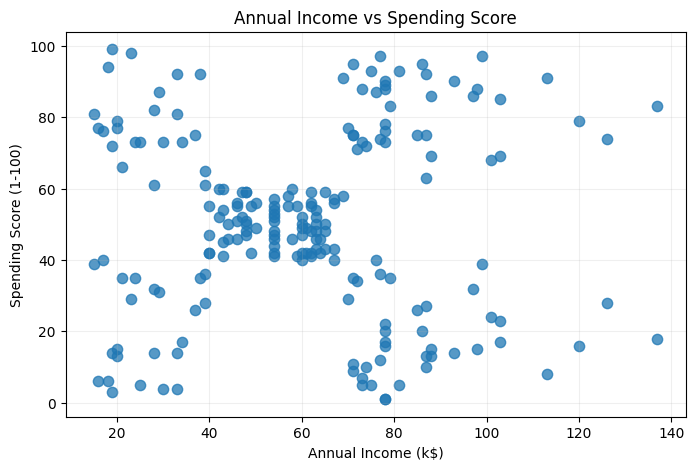

In [20]:
plt.figure(figsize=(8, 5))
plt.scatter(df["Annual Income (k$)"], df["Spending Score (1-100)"], s=55, alpha=0.75)
plt.title("Annual Income vs Spending Score")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.grid(alpha=0.2)
plt.show()


## 📏 Elección de parámetros
---
### Elegir `min_samples` y estimar `eps` con **k-distance plot**

Tomaremos como punto de partida:

- `min_samples = 3`
- `eps` a partir del **codo** del gráfico de distancias

La idea es encontrar el punto donde las distancias comienzan a crecer más rápido.


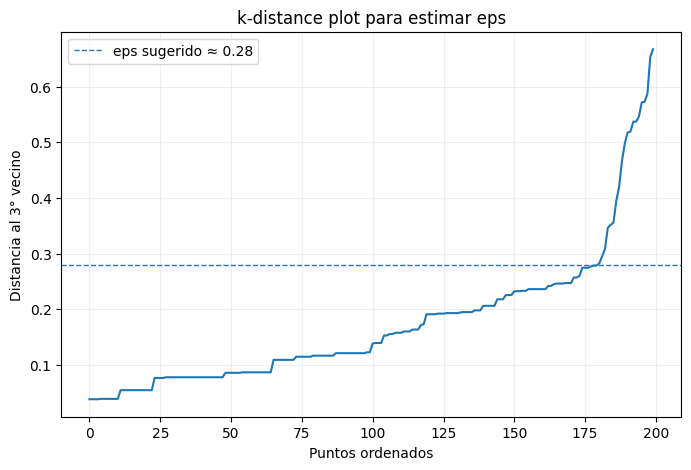

Percentiles de referencia:
75% -> 0.227
85% -> 0.247
90% -> 0.279
95% -> 0.499


In [ ]:
min_samples = 3

nbrs = NearestNeighbors(n_neighbors=min_samples)
nbrs.fit(X_scaled)

distances, indices = nbrs.kneighbors(X_scaled)

# Distancia al k-ésimo vecino
k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(8, 5))
plt.plot(k_distances)
plt.axhline(y=0.279, linestyle="--", linewidth=1, label="eps sugerido ≈ 0.28")
plt.title("k-distance plot para estimar eps")
plt.xlabel("Puntos ordenados")
plt.ylabel(f"Distancia al {min_samples}° vecino")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

print("Percentiles de referencia:")
for q in [0.75, 0.85, 0.90, 0.95]:
    print(f"{int(q*100)}% -> {np.quantile(k_distances, q):.3f}")


A partir del gráfico, el valor de `eps` puede ubicarse cerca de **0.28**.  
No existe un valor perfecto universal: en DBSCAN es normal probar varios escenarios y comparar resultados.


##  Aplicación de DBSCAN

In [34]:
eps = 0.28
dbscan = DBSCAN(eps=eps, min_samples=min_samples)
labels = dbscan.fit_predict(X_scaled)

df_dbscan = df.copy()
df_dbscan["DBSCAN_Cluster"] = labels

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = np.sum(labels == -1)
noise_pct = n_noise / len(df_dbscan) * 100

print(f"Clusters encontrados: {n_clusters}")
print(f"Puntos de ruido: {n_noise}")
print(f"Porcentaje de ruido: {noise_pct:.2f}%")


Clusters encontrados: 10
Puntos de ruido: 14
Porcentaje de ruido: 7.00%


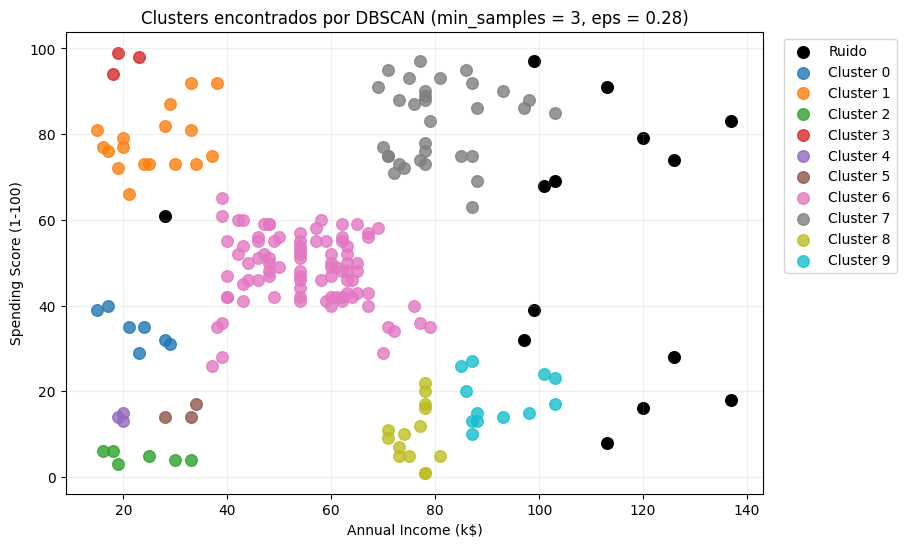

In [46]:
plt.figure(figsize=(9, 6))

unique_labels = sorted(df_dbscan["DBSCAN_Cluster"].unique())
for label in unique_labels:
    mask = df_dbscan["DBSCAN_Cluster"] == label
    if label == -1:
        plt.scatter(
            df_dbscan.loc[mask, "Annual Income (k$)"],
            df_dbscan.loc[mask, "Spending Score (1-100)"],
            s=70, c="black", label="Ruido"
        )
    else:
        plt.scatter(
            df_dbscan.loc[mask, "Annual Income (k$)"],
            df_dbscan.loc[mask, "Spending Score (1-100)"],
            s=70, alpha=0.8, label=f"Cluster {label}"
        )

plt.title("Clusters encontrados por DBSCAN (min_samples = 3, eps = 0.28)")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.grid(alpha=0.2)
plt.show()


In [38]:
df_dbscan["DBSCAN_Cluster"].value_counts().sort_index()

DBSCAN_Cluster
-1    14
 0     7
 1    17
 2     6
 3     3
 4     3
 5     3
 6    89
 7    32
 8    14
 9    12
Name: count, dtype: int64

### Resumen por cluster

In [36]:
cluster_summary = (
    df_dbscan[df_dbscan["DBSCAN_Cluster"] != -1]
    .groupby("DBSCAN_Cluster")[features]
    .agg(["mean", "count"])
    .round(2)
)

cluster_summary


Annual Income (k$)       Spending Score (1-100)      
                             mean count                   mean count
DBSCAN_Cluster                                                      
0                           22.43     7                  34.43     7
1                           25.82    17                  78.18    17
2                           23.50     6                   4.67     6
3                           20.00     3                  97.00     3
4                           19.67     3                  14.00     3
5                           31.67     3                  15.00     3
6                           55.02    89                  48.33    89
7                           80.50    32                  82.56    32
8                           75.93    14                  10.07    14
9                           92.17    12                  18.08    12

### Interpretación inicial
- DBSCAN logró identificar grupos sin indicar previamente cuántos clusters existían.
- Los puntos etiquetados como `-1` son observaciones que el modelo considera **ruido**.
- En este dataset, algunos segmentos quedan bien definidos, pero otros se agrupan en un cluster grande.  
  Esto sugiere que la densidad no es uniforme en todo el espacio, algo importante al interpretar DBSCAN.


##  Sensibilidad a los parámetros

Para ver cómo cambian los resultados, probaremos distintos valores de `eps` manteniendo fijo `min_samples = 5`.


In [ ]:
results = []

for eps_test in [0.30, 0.35, 0.40, 0.45]:
    model = DBSCAN(eps=eps_test, min_samples=5)
    test_labels = model.fit_predict(X_scaled)

    n_clusters_test = len(set(test_labels)) - (1 if -1 in test_labels else 0)
    n_noise_test = np.sum(test_labels == -1)

    mask = test_labels != -1
    if n_clusters_test >= 2 and mask.sum() > n_clusters_test:
        sil = silhouette_score(X_scaled[mask], test_labels[mask])
    else:
        sil = np.nan

    results.append({
        "eps": eps_test,
        "clusters": n_clusters_test,
        "noise_points": int(n_noise_test),
        "noise_%": round(n_noise_test / len(X_scaled) * 100, 2),
        "silhouette_sin_ruido": round(sil, 3) if not np.isnan(sil) else np.nan
    })

results_df = pd.DataFrame(results)
results_df


,eps,clusters,noise_points,noise_%,silhouette_sin_ruido
0,0.30,7,35,17.5,0.524
1,0.35,6,23,11.5,0.558
2,0.40,4,15,7.5,0.478
3,0.45,3,11,5.5,0.354


El cuadro anterior muestra que pequeños cambios en `eps` modifican bastante el número de clusters y la cantidad de ruido.  
Eso confirma que DBSCAN es muy útil, pero requiere una elección cuidadosa de parámetros.


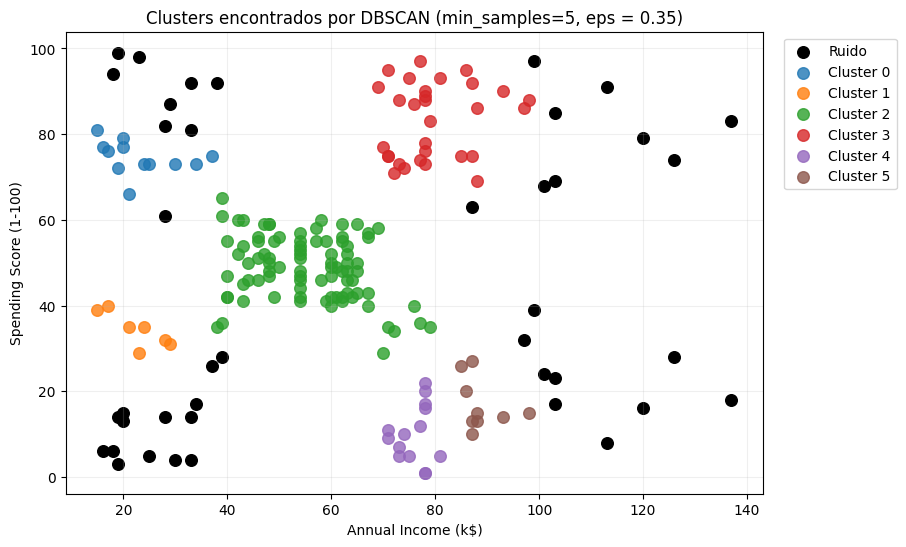

In [52]:
# Modelo con min_samples=5 y eps = 0.35 para comparar visualmente

dbscan_new = DBSCAN(eps=0.35, min_samples=5)
labels_new = dbscan_new.fit_predict(X_scaled)

plt.figure(figsize=(9, 6))

for label in sorted(set(labels_5)):
    mask = labels_5 == label
    if label == -1:
        plt.scatter(
            X.loc[mask, "Annual Income (k$)"],
            X.loc[mask, "Spending Score (1-100)"],
            s=70, c="black", label="Ruido"
        )
    else:
        plt.scatter(
            X.loc[mask, "Annual Income (k$)"],
            X.loc[mask, "Spending Score (1-100)"],
            s=70, alpha=0.8, label=f"Cluster {label}"
        )

plt.title("Clusters encontrados por DBSCAN (min_samples=5, eps = 0.35)")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.grid(alpha=0.2)
plt.show()

### Interpretación 
- Como podemos notar, al aumentaar *min_samples* a 5 y *eps* a 0.35, el algoritmo encuentra 6 clusters en lugar de los 10 que teniamos anteriormente. El ruido se reduce considerablemente ya que muchos puntos que antes quedaban aislados ahora son absorbidos por clusters cercanos gracias al radio eps más amplio.

In [54]:
print("Puntos ruido (noise_points):", np.sum(labels_new == -1))

Puntos ruido (noise_points): 23


##  Comparación rápida: DBSCAN vs K-Means

Para comparar, entrenaremos **K-Means** usando el mismo número de clusters encontrados por DBSCAN.  
La diferencia clave es que **K-Means obliga a que todos los puntos pertenezcan a algún cluster**, mientras que **DBSCAN puede dejar puntos como ruido**.


Silhouette K-Means: 0.528


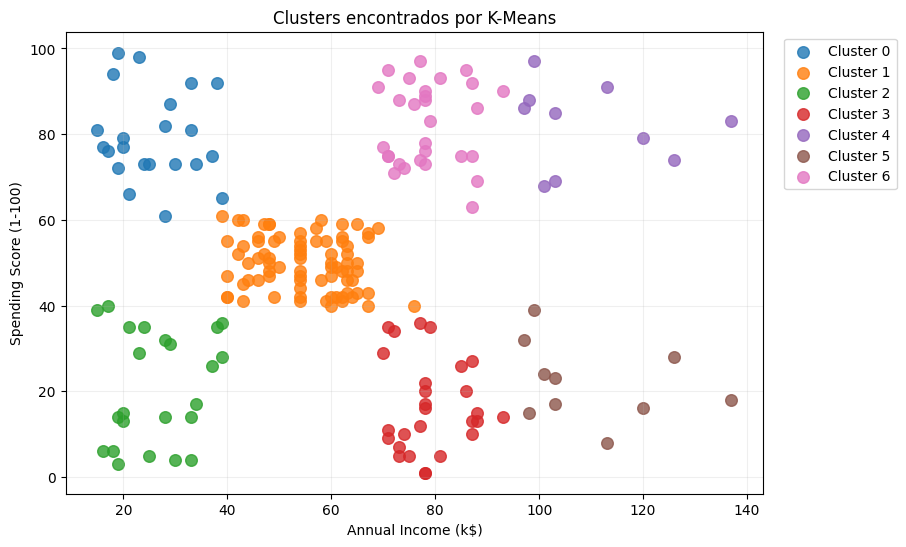

In [26]:
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=20)
kmeans_labels = kmeans.fit_predict(X_scaled)

df_compare = df.copy()
df_compare["KMeans_Cluster"] = kmeans_labels

print(f"Silhouette K-Means: {silhouette_score(X_scaled, kmeans_labels):.3f}")

plt.figure(figsize=(9, 6))
for label in sorted(df_compare["KMeans_Cluster"].unique()):
    mask = df_compare["KMeans_Cluster"] == label
    plt.scatter(
        df_compare.loc[mask, "Annual Income (k$)"],
        df_compare.loc[mask, "Spending Score (1-100)"],
        s=70, alpha=0.8, label=f"Cluster {label}"
    )

plt.title("Clusters encontrados por K-Means")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.grid(alpha=0.2)
plt.show()


## ✅ Conclusiones

- DBSCAN agrupa puntos por **densidad**, no por centroides.
- Sus parámetros más importantes son **`eps`** y **`min_samples`**.
- Una de sus mayores ventajas es que **detecta ruido automáticamente** y no exige fijar el número de clusters de antemano.
- En el dataset de clientes, DBSCAN encuentra estructura útil, pero también muestra que los datos tienen **densidades distintas**, lo que puede hacer que algunos grupos se fusionen.
- Frente a K-Means, DBSCAN es más flexible ante formas irregulares y outliers, mientras que K-Means produce particiones más rígidas y siempre asigna todos los puntos a un cluster.
- Con **`min_samples`** a 3 y **`eps`** a 0.28, DBSCAN detecto 10 clusters, con un configuración más sensible que captura grupos pequeños pero fragmenta zonas de densidad media
- Al cambiar a **`min_samples`** a 5 y **`eps`** a 0.35, los clusters se reducen a 6, el ruido baja y los grupos quedan más consolidados y compactos. Así, evidenciamos cómo pequeños ajustes en los parámetros cambian significativamente la agrupación de datos.

### Referencia consultada
- **DataCamp**: Material de apoyo para la explicación general de DBSCAN, en especial para la estimación de parametros mediante el k-distance plot
- **IBM Think**: Referencia teórica sobre el concepto de aprendizaje no supervisado y su relación con técnicas de clustering
- **Sickit-learn**: Documentación oficial empleada como guía para investigación del algoritmo de DBSCAN en python

### Enlaces:
- IBM Think — *Aprendizaje no supervisado*:  
  https://www.ibm.com/es-es/think/topics/unsupervised-learning

- Scikit-learn — *DBSCAN documentation*:  
  https://scikit-learn.org/stable/modules/generated/sklearn.cluster.DBSCAN.html
